## Import

In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score, precision_recall_curve, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt

## EDA

### 1. Data Load

In [43]:
df = pd.read_csv("features_wide.csv")
print(df.shape)

(267280, 25)


In [44]:
print(df.head())
print(df.info())

      cik     sic   year_q        Assets  AssetsCurrent  \
0  1750.0  3720.0  2010-Q3  1.501042e+09    863429000.0   
1  1750.0  3720.0  2010-Q4  1.501042e+09    863429000.0   
2  1750.0  3720.0  2011-Q1  1.501042e+09    863429000.0   
3  1750.0  3720.0  2011-Q2  1.500181e+09    846331000.0   
4  1750.0  3720.0  2011-Q3  1.703727e+09    913985000.0   

   CashAndCashEquivalentsAtCarryingValue  GeneralAndAdministrativeExpense  \
0                            112505000.0                              0.0   
1                            112505000.0                              0.0   
2                            112505000.0                              0.0   
3                            109391000.0                              0.0   
4                             79370000.0                              0.0   

   Goodwill  GrossProfit  \
0       0.0          0.0   
1       0.0          0.0   
2       0.0          0.0   
3       0.0          0.0   
4       0.0   70001000.0   

   IncomeLoss

In [45]:
print("Tên các cột:")
print(df.columns.tolist())

Tên các cột:
['cik', 'sic', 'year_q', 'Assets', 'AssetsCurrent', 'CashAndCashEquivalentsAtCarryingValue', 'GeneralAndAdministrativeExpense', 'Goodwill', 'GrossProfit', 'IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest', 'IncomeTaxExpenseBenefit', 'InterestExpense', 'Liabilities', 'LiabilitiesCurrent', 'NetIncomeLoss', 'NonoperatingIncomeExpense', 'OperatingExpenses', 'OperatingIncomeLoss', 'OtherNonoperatingIncomeExpense', 'Revenues', 'SellingGeneralAndAdministrativeExpense', 'ShareBasedCompensation', 'StockholdersEquity', 'WeightedAverageNumberOfDilutedSharesOutstanding', 'WeightedAverageNumberOfSharesOutstandingBasic']


## Data Preparation

In [46]:
# Kiểm tra giá trị thiếu
print("Giá trị thiếu theo cột:")
print(df.isnull().sum())

# Xử lý giá trị thiếu
df = df.dropna()

if 'year_q' in df.columns:
    df['date'] = pd.to_datetime(df['year_q'].str.replace('Q1', '-01-01').str.replace('Q2', '-04-01').str.replace('Q3', '-07-01').str.replace('Q4', '-10-01'))
else:
    print("Cảnh báo: Không tìm thấy cột 'year_q'.")

if 'cik' in df.columns and 'date' in df.columns:
    df = df.sort_values(['cik', 'date'])
else:
    print("Cảnh báo: Không tìm thấy cột 'cik' hoặc 'date'.")

Giá trị thiếu theo cột:
cik                                                                                            0
sic                                                                                            0
year_q                                                                                         0
Assets                                                                                         0
AssetsCurrent                                                                                  0
CashAndCashEquivalentsAtCarryingValue                                                          0
GeneralAndAdministrativeExpense                                                                0
Goodwill                                                                                       0
GrossProfit                                                                                    0
IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest    0
Income

## Feature Engineering

In [47]:
# Tạo lag features
df['NetIncome_Lag1'] = df.groupby('cik')['NetIncomeLoss'].shift(1)
df['Revenue_Lag1'] = df.groupby('cik')['Revenues'].shift(1)

# Tỷ lệ tăng trưởng
df['NetIncome_Growth'] = (df['NetIncomeLoss'] - df['NetIncome_Lag1']) / df['NetIncome_Lag1'].replace(0, np.nan).abs()
df['Revenue_Growth'] = (df['Revenues'] - df['Revenue_Lag1']) / df['Revenue_Lag1'].replace(0, np.nan).abs()

df['Current_Ratio'] = df['Assets'] / df['Liabilities'].replace(0, np.nan)
df['Debt_to_Equity'] = df['Liabilities'] / (df['Assets'] - df['Liabilities']).replace(0, np.nan)
df['ROA'] = df['NetIncomeLoss'] / df['Assets'].replace(0, np.nan)
df['Profit_Margin'] = df['NetIncomeLoss'] / df['Revenues'].replace(0, np.nan)

# Dự đoán Net Income quý tiếp theo
df['Target_Next_NetIncome'] = df.groupby('cik')['NetIncomeLoss'].shift(-1)

df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("Kích thước dữ liệu sau feature engineering:", df.shape)
print(df.head())

Kích thước dữ liệu sau feature engineering: (64026, 35)
        cik     sic   year_q       Assets  AssetsCurrent  \
212  2098.0  3420.0  2018-Q1  114730000.0     77818000.0   
213  2098.0  3420.0  2018-Q2  114730000.0     77818000.0   
214  2098.0  3420.0  2018-Q3  114730000.0     77818000.0   
215  2098.0  3420.0  2018-Q4  114729806.0     77817645.0   
216  2098.0  3420.0  2019-Q1  109478000.0     72992000.0   

     CashAndCashEquivalentsAtCarryingValue  GeneralAndAdministrativeExpense  \
212                              5911000.0                              0.0   
213                              5911000.0                              0.0   
214                              5911000.0                              0.0   
215                              5910770.0                              0.0   
216                              9338000.0                              0.0   

      Goodwill  GrossProfit  \
212  4696000.0   10564000.0   
213  4696000.0   25047000.0   
214  4696000.0 

## Train-Test Split (Time Series)

In [48]:
df = df.sort_values('date')

# Features
features = ['NetIncome_Lag1', 'Revenue_Lag1', 'NetIncome_Growth', 'Revenue_Growth', 'Current_Ratio', 'Debt_to_Equity', 'ROA', 'Profit_Margin']
X = df[features]
y = df['Target_Next_NetIncome']

# Train trên dữ liệu cũ, test trên dữ liệu mới
split_point = int(0.8 * len(df))
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print("Kích thước train:", X_train.shape, y_train.shape)
print("Kích thước test:", X_test.shape, y_test.shape)

Kích thước train: (51220, 8) (51220,)
Kích thước test: (12806, 8) (12806,)


## Data Cleaning

In [ ]:
# Loại bỏ outliers trong target (IQR method)
print("Xử lý Outliers")
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc dữ liệu không có outliers
mask_no_outliers = (y >= lower_bound) & (y <= upper_bound)
X_clean = X[mask_no_outliers]
y_clean = y[mask_no_outliers]

print(f"Dữ liệu gốc: {len(X)} samples")
print(f"Sau loại bỏ outliers: {len(X_clean)} samples (loại bỏ {len(X) - len(X_clean)} samples)")
print(f"Tỷ lệ loại bỏ: {((len(X) - len(X_clean)) / len(X) * 100):.1f}%")

# Normalize features
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(X_clean)

# Dùng target gốc
y_clean_original = y_clean

print("\nNormalization")
print(f"Features scaled - Mean: {X_clean_scaled.mean():.4f}, Std: {X_clean_scaled.std():.4f}")
print(f"Target range: {y_clean_original.min():.2f} to {y_clean_original.max():.2f}")

# Cập nhật train/test với dữ liệu
split_clean = int(0.8 * len(X_clean_scaled))
X_train_clean = X_clean_scaled[:split_clean]
X_test_clean = X_clean_scaled[split_clean:]
y_train_clean = y_clean_original[:split_clean]
y_test_clean = y_clean_original[split_clean:]

print(f"\nTrain set: {X_train_clean.shape[0]} samples")
print(f"Test set: {X_test_clean.shape[0]} samples")

=== XỬ LÝ OUTLIERS ===
Dữ liệu gốc: 64026 samples
Sau loại bỏ outliers: 50385 samples (loại bỏ 13641 samples)
Tỷ lệ loại bỏ: 21.3%

=== NORMALIZATION ===
Features scaled - Mean: 0.0000, Std: 1.0000
Target range: -86000000.00 to 133606000.00

Train set: 40308 samples
Test set: 10077 samples


## Modeling

In [ ]:
# Huấn luyện mô hình RandomForest Regression
model = RandomForestRegressor(n_estimators=150, max_depth=25, min_samples_split=5, random_state=42)
model.fit(X_train_clean, y_train_clean)

y_pred = model.predict(X_test_clean)

mae = mean_absolute_error(y_test_clean, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
r2 = 1 - (np.sum((y_test_clean - y_pred)**2) / np.sum((y_test_clean - y_test_clean.mean())**2))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# RMSLE
rmsle = np.sqrt(np.mean((np.log1p(np.abs(y_test_clean)) - np.log1p(np.abs(y_pred)))**2))
print(f"RMSLE: {rmsle:.4f}")

# MAPE
mask_meaningful = np.abs(y_test_clean) > 1e6
mape = np.mean(np.abs((y_test_clean[mask_meaningful] - y_pred[mask_meaningful]) / y_test_clean[mask_meaningful])) * 100 if mask_meaningful.sum() > 0 else np.nan
print(f"MAPE (meaningful values): {mape:.2f}%")

=== MODEL CẢI TIẾN (Outlier Removal + Normalization) ===
MAE: 11462681.10
RMSE: 21281638.70
R² Score: 0.6272
RMSLE: 2.2319
MAPE (meaningful values): 95.13%


### Time Series Forecasting

In [ ]:
# RandomForest cho Time Series Forecasting
ts_model = RandomForestRegressor(n_estimators=150, max_depth=25, min_samples_split=5, random_state=42)
ts_model.fit(X_train_clean, y_train_clean)

y_pred_ts = ts_model.predict(X_test_clean)

mae_ts = mean_absolute_error(y_test_clean, y_pred_ts)
rmse_ts = np.sqrt(mean_squared_error(y_test_clean, y_pred_ts))
print(f"Time Series - MAE: {mae_ts:.2f}, RMSE: {rmse_ts:.2f}")

Time Series - MAE: 11462681.10, RMSE: 21281638.70


### Classification: Predict Financial Distress or Growth Categories

In [ ]:
df['Growth_Category'] = pd.cut(df['NetIncome_Growth'], bins=[-np.inf, -0.1, 0.1, np.inf], labels=['Decline', 'Stable', 'High Growth'])

# Classification
y_class = df['Growth_Category'][mask_no_outliers].dropna()
X_class_clean = X_clean.loc[y_class.index]

# Chia train/test (time series)
split_class = int(0.8 * len(X_class_clean))
X_train_class = scaler.transform(X_class_clean[:split_class])  # Normalize
X_test_class = scaler.transform(X_class_clean[split_class:])
y_train_class = y_class[:split_class]
y_test_class = y_class[split_class:]

# RandomForest Classifier
class_model = RandomForestClassifier(n_estimators=150, max_depth=20, min_samples_split=5, random_state=42)
class_model.fit(X_train_class, y_train_class)

y_pred_class = class_model.predict(X_test_class)

f1 = f1_score(y_test_class, y_pred_class, average='weighted')
print(f"Classification - F1 Score: {f1:.4f}")
print(classification_report(y_test_class, y_pred_class))

Classification - F1 Score: 0.9999
              precision    recall  f1-score   support

     Decline       1.00      1.00      1.00      4054
 High Growth       1.00      1.00      1.00      3813
      Stable       1.00      1.00      1.00      2210

    accuracy                           1.00     10077
   macro avg       1.00      1.00      1.00     10077
weighted avg       1.00      1.00      1.00     10077



## Insights (Feature importance)

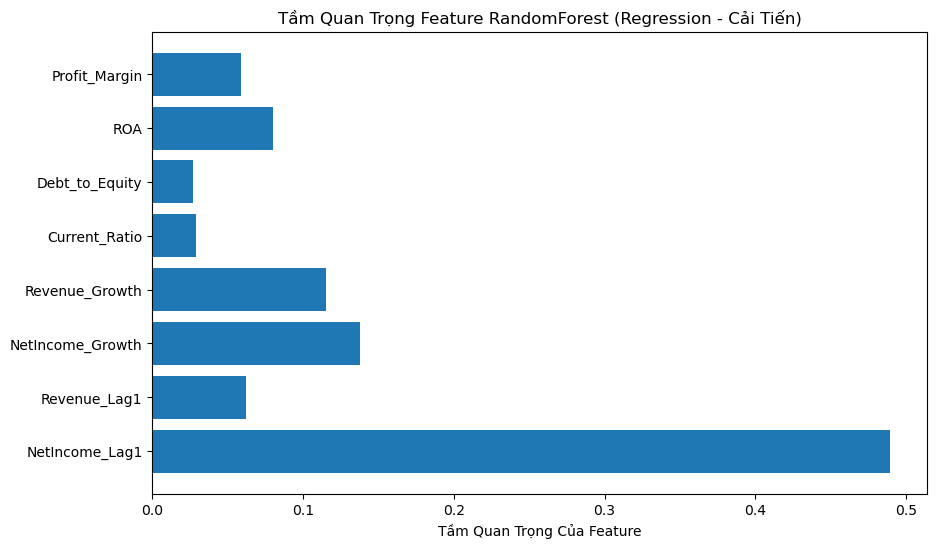

Top features cho Regression:
Revenue_Lag1: 0.0621
ROA: 0.0800
Revenue_Growth: 0.1155
NetIncome_Growth: 0.1375
NetIncome_Lag1: 0.4897


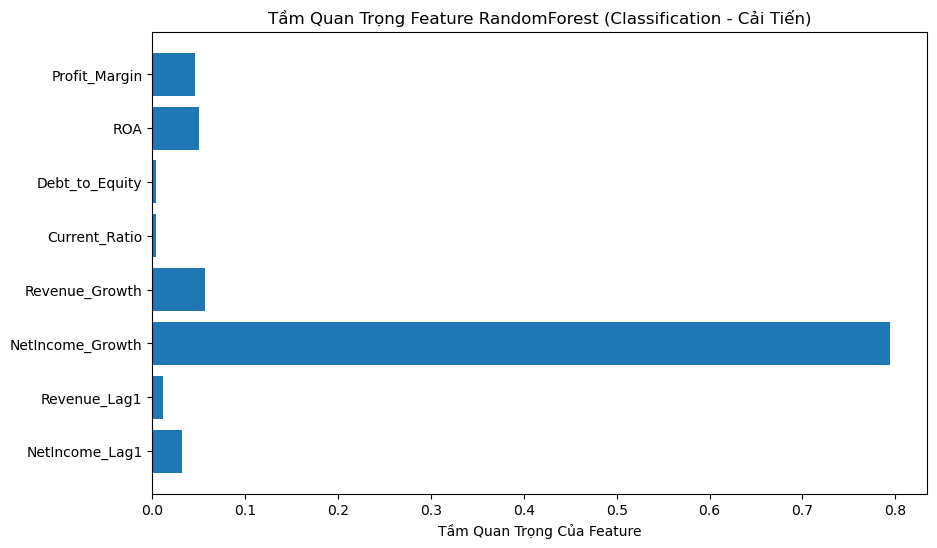

Top features cho Classification:
NetIncome_Lag1: 0.0317
Profit_Margin: 0.0464
ROA: 0.0499
Revenue_Growth: 0.0569
NetIncome_Growth: 0.7947


In [ ]:
feature_importance_reg = model.feature_importances_
features_list = features

plt.figure(figsize=(10, 6))
plt.barh(features_list, feature_importance_reg)
plt.xlabel('Tầm Quan Trọng Của Feature')
plt.title('Tầm Quan Trọng Feature RandomForest (Regression)')
plt.show()

sorted_idx_reg = feature_importance_reg.argsort()
print("Top features cho Regression:")
for idx in sorted_idx_reg[-5:]:
    print(f"{features_list[idx]}: {feature_importance_reg[idx]:.4f}")

feature_importance_class = class_model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(features_list, feature_importance_class)
plt.xlabel('Tầm Quan Trọng Của Feature')
plt.title('Tầm Quan Trọng Feature RandomForest (Classification)')
plt.show()

sorted_idx_class = feature_importance_class.argsort()
print("Top features cho Classification:")
for idx in sorted_idx_class[-5:]:
    print(f"{features_list[idx]}: {feature_importance_class[idx]:.4f}")